# Supplementary: Open Data Score vs. Encoding Consistency (Per Journal)

This notebook extends the analysis of Fig. 4b to the individual journal level (171 data points instead of 17 publishers). It tests whether the negative correlation between policy strictness and encoding consistency holds at finer granularity.

In [14]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

## Setup

Import analysis tools and configure matplotlib.

In [15]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

## Load processed data

In [16]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

## Compute consistency and scores per journal

For each journal, compute the fraction of consistently answered questions (excluding questions 10 & 11) and the journal-level ODS. Then calculate the Pearson correlation.

In [17]:
inconsitencies_dict = {}

for publisher, journals in processed_data.items():
    for journal, data in journals.items():
        inconsitencies = {"Consistent": 0, "Inconsistent": 0}

        for question, answer in data.items():
            
            if question == "data_recommended" or question == "data_required":
                continue

            if not answer.has_multiple_answers():
                continue

            if answer.has_discrepancies():
                inconsitencies["Inconsistent"] += 1
            else:
                inconsitencies["Consistent"] += 1
    
        print(publisher, journal, inconsitencies)
        key = (publisher, journal)
        inconsitencies_dict[key] = inconsitencies

ACS the_journal_of_organic_chemistry {'Consistent': 0, 'Inconsistent': 0}
ACS journal_of_the_american_society_for_mass_spectrometry {'Consistent': 12, 'Inconsistent': 5}
ACS acs_omega {'Consistent': 12, 'Inconsistent': 5}
ACS jacs {'Consistent': 13, 'Inconsistent': 4}
ACS chemrxiv {'Consistent': 0, 'Inconsistent': 0}
ACS applied_materials_and_interfaces {'Consistent': 13, 'Inconsistent': 4}
ACS acs_es_and_t_engineering {'Consistent': 13, 'Inconsistent': 4}
ACS inorganic_chemistry {'Consistent': 10, 'Inconsistent': 7}
ACS jacs_au {'Consistent': 13, 'Inconsistent': 4}
ACS accounts_of_chemical_research {'Consistent': 0, 'Inconsistent': 0}
ACS journal_of_medicinal_chemistry {'Consistent': 12, 'Inconsistent': 5}
ACS environmental_science_and_technology {'Consistent': 9, 'Inconsistent': 8}
ACS accounts_of_materials_research {'Consistent': 13, 'Inconsistent': 4}
ACS acs_energy_letters {'Consistent': 15, 'Inconsistent': 2}
ACS the_journal_of_physical_chemistry_c {'Consistent': 12, 'Inconsisten

In [18]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats
import numpy as np

inconsitency_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    for journal, journal_results in publisher_results.items():
        score = get_journal_score(journal_results)
        

        key = (publisher, journal)

        n = inconsitencies_dict[key]["Consistent"] + inconsitencies_dict[key]["Inconsistent"]

        if n == 0:
            continue

        inconsitency = inconsitencies_dict[key]["Consistent"] / n
        inconsitency_list.append(inconsitency)

        score_list.append(score)

        print(score, inconsitency)
            
# Pearson correlation coefficient
r, p_value = stats.pearsonr(inconsitency_list, score_list)
print(f"n {len(inconsitency_list)} Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

0.19631578947368422 0.7058823529411765
0.19631578947368422 0.7058823529411765
0.20421052631578948 0.7647058823529411
0.2068421052631579 0.7647058823529411
0.19631578947368422 0.7647058823529411
0.29263157894736846 0.5882352941176471
0.19631578947368422 0.7647058823529411
0.22263157894736843 0.7058823529411765
0.31000000000000005 0.5294117647058824
0.20421052631578948 0.7647058823529411
0.20421052631578948 0.8823529411764706
0.1394736842105263 0.7058823529411765
0.17 0.8823529411764706
0.17 0.9411764705882353
0.17 0.8823529411764706
0.17 0.8823529411764706
0.17 0.9411764705882353
0.17 0.9411764705882353
0.17 0.9411764705882353
0.18736842105263157 0.7647058823529411
0.21368421052631578 0.8235294117647058
0.17 0.8823529411764706
0.17 0.9411764705882353
0.17 0.9411764705882353
0.17 0.9411764705882353
0.17 0.9411764705882353
0.2131578947368421 1.0
0.2131578947368421 1.0
0.2131578947368421 0.9411764705882353
0.2131578947368421 0.9411764705882353
0.2131578947368421 1.0
0.2131578947368421 1.0


In [19]:
df = pd.DataFrame({
    'Inconsitency': inconsitency_list,
    'Open data score': score_list
})

# Write the DataFrame to a CSV file
df.to_csv('../../data/processed/policy_vs_consitency_per_journal.csv', index=False)

## Figure: ODS vs. consistency rate (per journal)

Scatter plot at the journal level.

Output saved to `data/processed/policy_vs_consitency_per_journal.pdf`

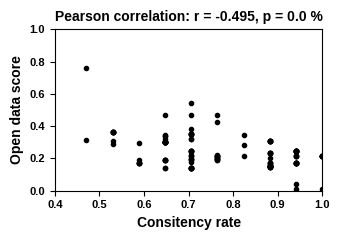

In [20]:
fig = plt.figure(figsize=(3.5, 2.5))

plt.plot(inconsitency_list, score_list, ".k")
plt.title(f"Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")
plt.xlabel("Consitency rate")
plt.ylabel("Open data score")
plt.xlim((0.4, 1.0))
plt.ylim((0.0, 1.0))
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_consitency_per_journal.pdf")

In [21]:
#remove outliers and recalculate Pearson correlation coefficient
inconsitency_list_filtered = []
score_list_filtered = []
for inconsitency, score in zip(inconsitency_list, score_list):
    if score < 0.75:  # Example threshold to remove outliers
        inconsitency_list_filtered.append(inconsitency)
        score_list_filtered.append(score)
r, p_value = stats.pearsonr(inconsitency_list_filtered, score_list_filtered)
print(f"After removing outliers: Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

After removing outliers: Pearson correlation: r = -0.483, p = 0.0 %
